In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'mixed')

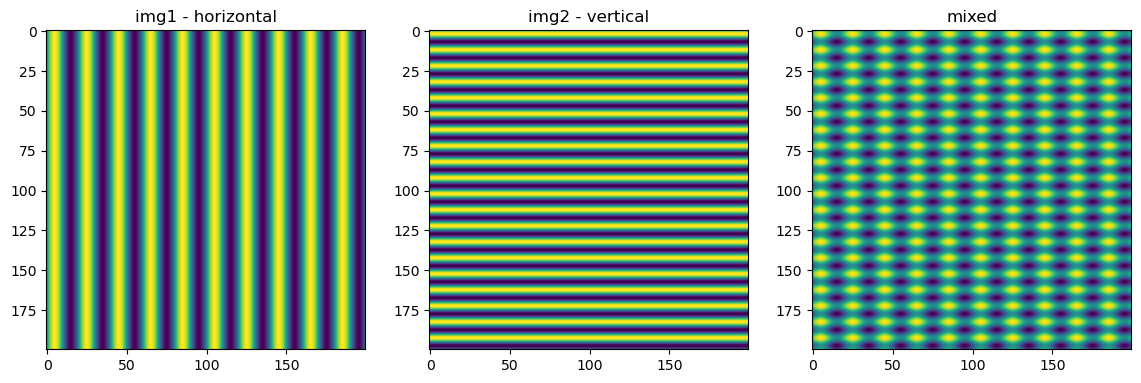

In [96]:
N = 200
x = np.arange(N) / N
y = np.arange(N) / N

x_grid, y_grid = np.meshgrid(x, y)
f1 = 10
img1 = np.sin(2 * np.pi * f1 * x_grid) 

x_grid, y_grid = np.meshgrid(x, y)
f2 = 20
img2 = np.sin(2 * np.pi * f2 * y_grid)

mixed = img1 + img2

plt.figure(figsize=(14, 9))
plt.subplot(131)
plt.imshow(img1)
plt.title("img1 - horizontal")

plt.subplot(132)
plt.imshow(img2)
plt.title("img2 - vertical")

plt.subplot(133)
plt.imshow(mixed)
plt.title("mixed")

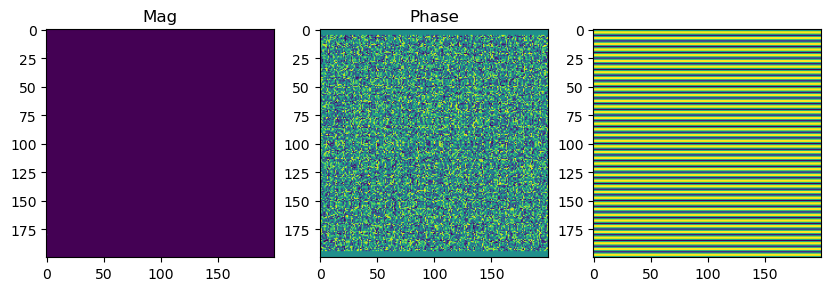

In [97]:
# LOOKS LIKE YOU ARE GOING TO THE FREQUENCY REALM BUD
F = np.fft.fft2(mixed)
height, width = F.shape

F = np.fft.fftshift(F)
# F[:, width//2 - 5:width//2+5] = 0
F[height//2 - 5:height//2+5, :] = 0

F = np.fft.fftshift(F)
recon = np.fft.ifft2(F)

plt.figure(figsize=(10, 10))
plt.subplot(231)
plt.imshow(np.log1p(np.abs(F)))
plt.title("Mag")

plt.subplot(232)
plt.imshow(np.angle(F))
plt.title("Phase")

plt.subplot(233)
plt.imshow(np.abs(recon))

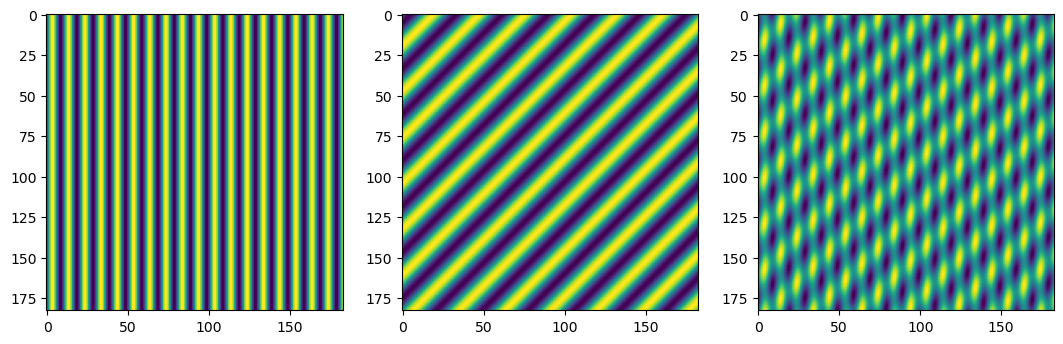

In [98]:
sinephase = [0, np.pi/4]
sinefreq = [0.1, 0.05]

lims = [-91, 91]
x, y = np.meshgrid(np.arange(lims[0], lims[1]+1), np.arange(lims[0], lims[1]+1))

xp = x * np.cos(sinephase[0]) + y * np.sin(sinephase[0])
img1 = np.sin(2 * np.pi * sinefreq[0] * xp)

xp = x * np.cos(sinephase[1]) + y * np.sin(sinephase[1])
img2 = np.sin(2 * np.pi * sinefreq[1] * xp)

img = img1 + img2

plt.figure(figsize=(13, 13))
plt.subplot(131); plt.imshow(img1)
plt.subplot(132); plt.imshow(img2)
plt.subplot(133); plt.imshow(img)

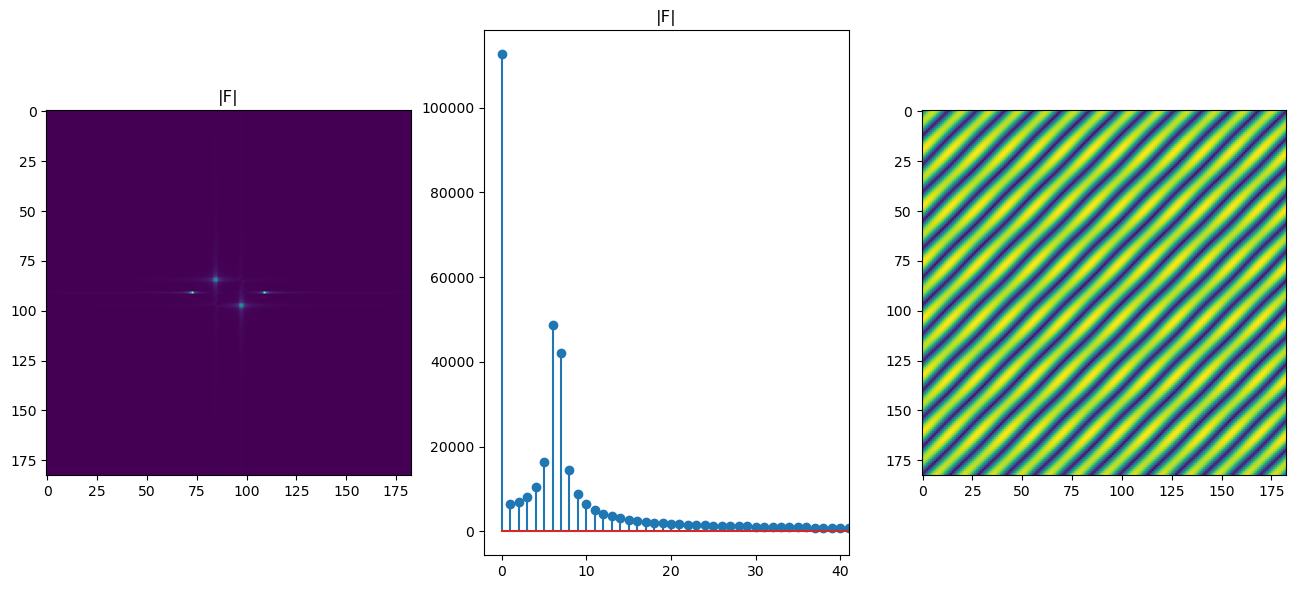

In [138]:
img_freq = np.fft.fft2(img)
img_abs, img_phase = np.abs(img_freq), np.angle(img_freq)

img_freq[0, :] = 0
recon = np.fft.ifft2(img_freq)

plt.figure(figsize=(16, 15))

plt.subplot(231)
plt.imshow(np.fft.fftshift(img_abs))
plt.title("|F|")

plt.subplot(232)
plt.stem(np.sum(img_abs, axis=1))
plt.title("|F|")
plt.xlim(-2.1, 41)

plt.subplot(233)
plt.imshow(np.abs(recon))